In [1]:
import tensorflow as tf
import cv2
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score,confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

C:\Users\ANAMIKA\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
data = pd.read_csv('fer2013.csv')
data.head()

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [3]:
data['emotion'].unique()

array([0, 2, 4, 6, 3, 5, 1])

In [4]:
emotion = ['Angry','Disgust','Fear','Happy','Sad','Surprise','Neutral']
training_data = pd.get_dummies(data,columns = ['emotion'] )

In [5]:
training_data.shape

(35887, 9)

In [6]:
training_data.head()

,pixels,Usage,emotion_0,emotion_1,emotion_2,emotion_3,emotion_4,emotion_5,emotion_6
0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training,True,False,False,False,False,False,False
1,151 150 147 155 148 133 111 140 170 174 182 15...,Training,True,False,False,False,False,False,False
2,231 212 156 164 174 138 161 173 182 200 106 38...,Training,False,False,True,False,False,False,False
3,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training,False,False,False,False,True,False,False
4,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training,False,False,False,False,False,False,True


In [7]:
training = training_data[training_data['Usage'] == 'Training']
test = training_data[training_data['Usage'] == 'PublicTest']
t = training['pixels']
X_train = []
for x in t:
  temp = x.split(' ')
  temp = [int(_) for _ in temp]
  temp = np.array(temp)
  temp = temp.reshape(48,48)
  temp  = temp/255 
  X_train.append(temp)
X_test = []
t = test['pixels']
for x in t:
  temp = x.split(' ')
  temp = [int(_) for _ in temp]
  temp = np.array(temp)
  temp = temp.reshape(48,48)
  temp  = temp/255 
  X_test.append(temp)

In [8]:
y_test = training_data[training_data['Usage'] == 'PublicTest'].drop(['pixels','Usage'],axis=1)
y_train = training_data[training_data['Usage'] == 'Training'].drop(['pixels','Usage'],axis=1)
print(y_test)

       emotion_0  emotion_1  emotion_2  emotion_3  emotion_4  emotion_5  \
28709       True      False      False      False      False      False   
28710      False       True      False      False      False      False   
28711      False      False      False      False       True      False   
28712      False      False      False      False      False      False   
28713      False      False      False       True      False      False   
...          ...        ...        ...        ...        ...        ...   
32293      False      False      False      False       True      False   
32294      False      False      False       True      False      False   
32295      False      False      False      False       True      False   
32296      False      False      False      False       True      False   
32297      False      False      False      False       True      False   

       emotion_6  
28709      False  
28710      False  
28711      False  
28712       True  
2871

In [9]:
X_train = np.array(list(np.array(X_train))).reshape(-1,48,48,1)
X_test = np.array(list(np.array(X_test))).reshape(-1,48,48,1)

In [10]:
s = y_train.sum(axis=0)
print(s)

emotion_0    3995
emotion_1     436
emotion_2    4097
emotion_3    7215
emotion_4    4830
emotion_5    3171
emotion_6    4965
dtype: int64


In [11]:
y_train.shape

(28709, 7)

In [12]:
X_train.shape

(28709, 48, 48, 1)

In [13]:
from tensorflow.keras.layers import Conv2D,BatchNormalization,MaxPooling2D,Dense,Dropout,SpatialDropout2D,Flatten
from tensorflow.keras.regularizers import l1
model = tf.keras.models.Sequential()
model.add(Conv2D(64, kernel_size=3, activation='relu', padding="same", input_shape=(48,48,1),kernel_regularizer=l1(1e-6)))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (5, 5), activation='relu', padding='same',kernel_regularizer=l1(1e-6)))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(512, (3, 3), activation='relu', padding='same',kernel_regularizer=l1(1e-6)))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(512, (3, 3), activation='relu', padding='same',kernel_regularizer=l1(1e-6)))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(SpatialDropout2D(0.5))
model.add(Flatten())

model.add(Dense(256,activation = 'relu',kernel_regularizer=l1(1e-6)))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(512,activation = 'relu',kernel_regularizer=l1(1e-6)))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Dense(7,activation = 'softmax'))

C:\Users\ANAMIKA\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 3, 3, 512)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,58

 Total params: 4,478,727 (17.08 MB)

 Trainable params: 4,474,759 (17.07 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [15]:
model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(),metrics=['accuracy'])

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',      
    patience=5,              
    restore_best_weights=True,  
    min_delta=0.001         
)

In [17]:
history = model.fit(X_train,y_train,epochs=25,callbacks=[early_stop], batch_size=128,validation_split=0.1,shuffle=True)

Epoch 1/25
202/202 ━━━━━━━━━━━━━━━━━━━━ 855s 4s/step - accuracy: 0.2026 - loss: 2.3419 - val_accuracy: 0.2550 - val_loss: 2.5520
Epoch 2/25
202/202 ━━━━━━━━━━━━━━━━━━━━ 454s 2s/step - accuracy: 0.2419 - loss: 2.0002 - val_accuracy: 0.1390 - val_loss: 2.8475
Epoch 3/25
202/202 ━━━━━━━━━━━━━━━━━━━━ 435s 2s/step - accuracy: 0.3240 - loss: 1.8077 - val_accuracy: 0.1435 - val_loss: 2.7330
Epoch 4/25
202/202 ━━━━━━━━━━━━━━━━━━━━ 1149s 6s/step - accuracy: 0.4221 - loss: 1.5863 - val_accuracy: 0.4037 - val_loss: 1.5881
Epoch 5/25
202/202 ━━━━━━━━━━━━━━━━━━━━ 582s 3s/step - accuracy: 0.4609 - loss: 1.4722 - val_accuracy: 0.4716 - val_loss: 1.4762
Epoch 6/25
202/202 ━━━━━━━━━━━━━━━━━━━━ 707s 2s/step - accuracy: 0.5006 - loss: 1.3763 - val_accuracy: 0.5061 - val_loss: 1.3623
Epoch 7/25
202/202 ━━━━━━━━━━━━━━━━━━━━ 439s 2s/step - accuracy: 0.5312 - loss: 1.3156 - val_accuracy: 0.5246 - val_loss: 1.3269
Epoch 8/25
202/202 ━━━━━━━━━━━━━━━━━━━━ 434s 2s/step - accuracy: 0.5481 - loss: 1.2761 - val_acc

In [18]:
y_pred = model.predict(X_test)
y_predicted = y_pred.argmax(axis=1)

113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 112ms/step


Probabilities are:- [8.2514090e-03 1.2563334e-03 6.1505627e-02 5.6307840e-01 5.5006612e-04
 3.6333802e-01 2.0201625e-03]
Predicted Emotion:- Happy
Original Emotion:- Happy


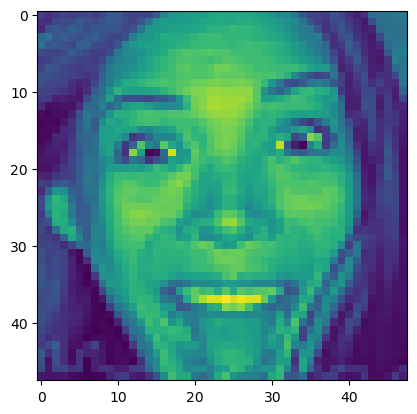

In [21]:
img=1112

plt.imshow(X_test[img].reshape(48,48))
print("Probabilities are:-", y_pred[img])
print("Predicted Emotion:-", emotion[y_predicted[img]])
original_emotion = emotion[np.argmax(y_test.iloc[img].values)]
print("Original Emotion:-", original_emotion)

In [22]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

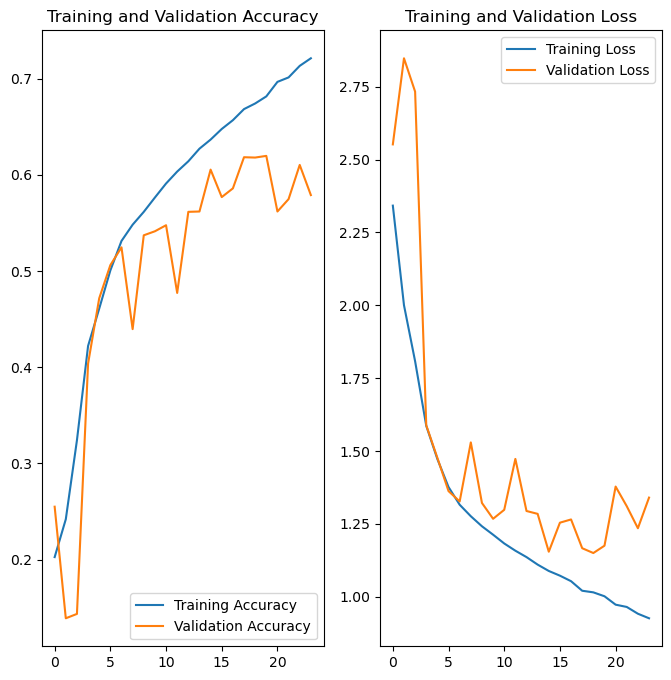

In [24]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))   # number of epochs actually trained

plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [27]:
y_test_labels = np.argmax(y_test.values, axis=1)

print("Accuracy= ", accuracy_score(y_test_labels, y_predicted))
print("Recall= ", recall_score(y_test_labels, y_predicted, average='macro'))
print("F1 Score= ", f1_score(y_test_labels, y_predicted, average='macro'))
print("Precision= ", precision_score(y_test_labels, y_predicted, average='macro'))

Accuracy=  0.616049038729451
Recall=  0.5830799799395011
F1 Score=  0.5809280047438964
Precision=  0.586208224969561


In [29]:
model.save_weights("deep_weights.weights.h5")